
Recommendation Engines 
- Collaborative Filtering
- Open Source Packages for Recommendation
- Specialized Recommenders
- Integrating Deep Learning and Generative AI into Recommendation Engines
- Evaluation Metrics

### Collaborative Filtering

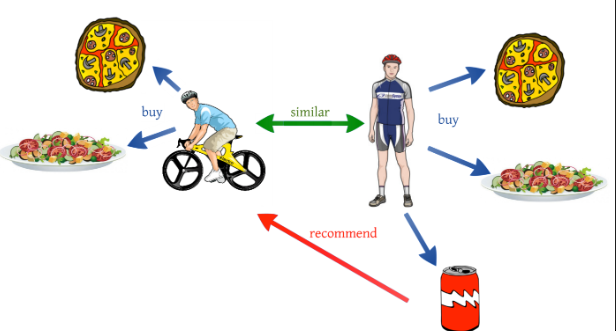

Collaborative Filtering ("CF") focuses on collecting and analyzing data on user behavior, activities, and preferences, to predict what a person will like, based on their similarity to other users. To plot and calculate these similarities, CF uses matrix methods. 

In the Content-based Filtering lab, we relied extensively on metadata about particular films. Classic CF doesnt require this metadata; it simply picks items to recommend based on what we know about the user, reflecting the behavior and preferences of neighbors. 

There are two general approaches for identifying neighbors

- KNN is a machine learning algorithm to find the k nearest neighbors, based on similarity of common content reviews. Predictions are based on the behavior and preferences of those neighbors. 
- Latent Factor Model (LFM) projects users and items into a joint latent factor space. The data is large and sparse, since most users have reviewed only a small fraction of the available content. LFM factors the sparse data into a denser matrix ("Matrix Factorization") with a lower dimension which is able to make useful 'interpolations' of the joint latent factor space

CF rose to prominence after winning the Netflix Prize in 2009

In [40]:
# Download the actual data from

from tensorflow import keras
from zipfile import ZipFile
from pathlib import Path
import pandas as pd

import tensorflow as tf 
import numpy as np
from tqdm.notebook import tqdm
import kagglehub
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='sklearn')

from sklearn.neighbors import NearestNeighbors

#import scipy.stats as stats
#from sklearn.feature_extraction.text import TfidfVectorizer as TfV
#from sklearn.preprocessing import normalize
#from sklearn.metrics.pairwise import linear_kernel
#import json


movielens_data_file_url = (
    "http://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
)
movielens_zipped_file = keras.utils.get_file(
    "ml-latest-small.zip", movielens_data_file_url, extract=False
)
keras_datasets_path = Path(movielens_zipped_file).parents[0]
movielens_dir = keras_datasets_path / "ml-latest-small"

# Only extract the data the first time the script is run.
if not movielens_dir.exists():
    with ZipFile(movielens_zipped_file, "r") as zip:
        # Extract files
        print("Extracting all the files now...")
        zip.extractall(path=keras_datasets_path)
        print("Done!")
        


In [41]:

def get_subset(df, number):
    """
    just get a subset of a large dataset for debug purpose
    """
    rids = np.arange(df.shape[0])
    np.random.seed(42)
    np.random.shuffle(rids)
    return df.iloc[rids[:number], :].copy()

### Data

Let's return to the MovieLens dataset. 

In addition to the movie data we worked with earlier, it has a compilation of ratings assigned by a set of users to a set of movies. 

Our objective is to predict ratings a user would assign to movies the user has not yet watched. The movies with the highest predicted ratings can be recommended to the user.

## First, load the data and apply preprocessing

In [42]:
ratings_file = movielens_dir / "ratings.csv"
df_ratings = pd.read_csv(ratings_file)

We will need to perform some preprocessing to encode users and movies as integer indices.

In [43]:
user_ids = df_ratings["userId"].unique().tolist()
user2user_encoded = {x: i for i, x in enumerate(user_ids)}
userencoded2user = {i: x for i, x in enumerate(user_ids)}

movie_ids = df_ratings["movieId"].unique().tolist()
movie2movie_encoded = {x: i for i, x in enumerate(movie_ids)}
movie_encoded2movie = {i: x for i, x in enumerate(movie_ids)}

df_ratings["user"] = df_ratings["userId"].map(user2user_encoded)
df_ratings["movie"] = df_ratings["movieId"].map(movie2movie_encoded)

num_users = len(user2user_encoded)
num_movies = len(movie_encoded2movie)
df_ratings["rating"] = df_ratings["rating"].values.astype(np.float32)

# min and max ratings will be used to normalize the ratings later
min_rating = min(df_ratings["rating"])
max_rating = max(df_ratings ["rating"])
print(    "Number of users: {}, Number of Movies: {}, Min rating: {}, Max rating: {}".format(        num_users, num_movies, min_rating, max_rating    ))

Number of users: 610, Number of Movies: 9724, Min rating: 0.5, Max rating: 5.0


### Prepare training and validation data

In [44]:
df_ratings = df_ratings.sample(frac=1, random_state=42)
x = df_ratings[["user", "movie"]].values
# Normalize the targets between 0 and 1. Makes it easy to train.
y = df_ratings["rating"].apply(lambda x: (x - min_rating) / (max_rating - min_rating)).values
# Assuming training on 90% of the data and validating on 10%.
train_indices = int(0.9 * df_ratings.shape[0])
x_train, x_val, y_train, y_val = (
    x[:train_indices],
    x[train_indices:],
    y[:train_indices],
    y[train_indices:],
)

### Create the model

Users and movies are embedded into 50-dimensional vectors. These embeddings are learned iteratively as the model trains. 

The model computes a match score between user and movie embeddings via a dot product, and adds a per-movie and per-user bias. The match score is scaled to the [0, 1] interval via a sigmoid (since our ratings are normalized to this range).



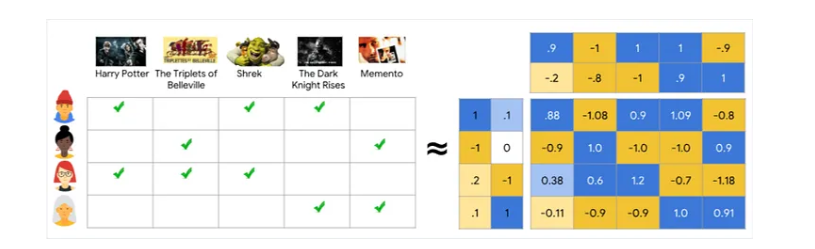

https://medium.com/@weidagang/demystifying-neural-networks-collaborative-filtering-and-matrix-factorization-f21c4f41c1bd

In [45]:
from tensorflow.keras import layers

EMBEDDING_SIZE = 50
class RecommenderNet(keras.Model):
    def __init__(self, num_users, num_movies, embedding_size, **kwargs):
        super(RecommenderNet, self).__init__(**kwargs)
        self.num_users = num_users
        self.num_movies = num_movies
        self.embedding_size = embedding_size
        self.user_embedding = layers.Embedding(
            num_users,
            embedding_size,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6),
            )
        self.user_bias = layers.Embedding(num_users, 1)
        self.movie_embedding = layers.Embedding(
            num_movies,
            embedding_size,
            embeddings_initializer="he_normal",
            embeddings_regularizer=keras.regularizers.l2(1e-6),
            )
        self.movie_bias = layers.Embedding(num_movies, 1)
        
    def call(self, inputs):
        user_vector = self.user_embedding(inputs[:, 0])
        user_bias = self.user_bias(inputs[:, 0])
        movie_vector = self.movie_embedding(inputs[:, 1])
        movie_bias = self.movie_bias(inputs[:, 1])
        dot_user_movie = tf.tensordot(user_vector, movie_vector, 2)
        # Add all the components (including bias)
        x = dot_user_movie + user_bias + movie_bias
        # The sigmoid activation forces the rating to between 0 and 1
        return tf.nn.sigmoid(x)

model = RecommenderNet(num_users, num_movies, EMBEDDING_SIZE)
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(learning_rate=0.001)
    )

### Training RecommenderNet

We train the weights via gradient descent using all available user-movie pairs to minimize the error between predicted and actual rating. Our small dataset should train in under 2 minutes

In [47]:
history = model.fit(
    x=x_train,
    y=y_train,
    batch_size=64,
    epochs=5,
    verbose=1,
    validation_data=(x_val, y_val),
)

Epoch 1/5
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 0.6358 - val_loss: 0.6203
Epoch 2/5
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 0.6131 - val_loss: 0.6179
Epoch 3/5
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 0.6085 - val_loss: 0.6157
Epoch 4/5
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - loss: 0.6071 - val_loss: 0.6144
Epoch 5/5
1418/1418 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 0.6064 - val_loss: 0.6124


The output should look something like this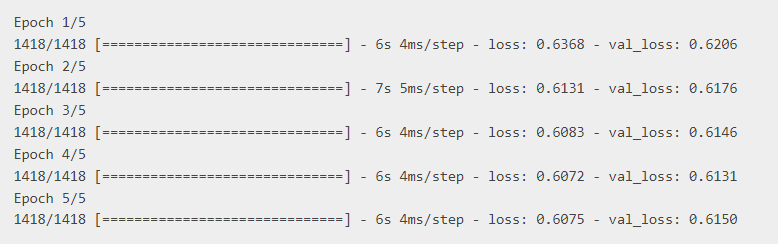

### Plot training and validation loss

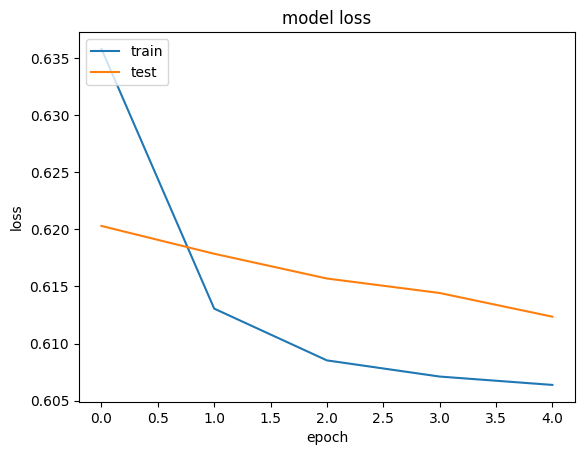

In [48]:
from matplotlib import pyplot as plt
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "test"], loc="upper left")
plt.show()

### Show top 10 movie recommendations to a user

In [49]:
movie_file = movielens_dir / "movies.csv"
df_movies = pd.read_csv(movie_file)

# Let us get a user and see the top recommendations.
user_id = df_ratings .userId.sample(1).iloc[0]
movies_watched_by_user = df_ratings[df_ratings.userId == user_id]
movies_not_watched = df_movies[    ~df_movies["movieId"].isin(movies_watched_by_user.movieId.values)]["movieId"]
movies_not_watched = list(    set(movies_not_watched).intersection(set(movie2movie_encoded.keys())))
movies_not_watched = [[movie2movie_encoded.get(x)] for x in movies_not_watched]
user_encoder = user2user_encoded.get(user_id)
user_movie_array = np.hstack(    ([[user_encoder]] * len(movies_not_watched), movies_not_watched))
ratings = model.predict(user_movie_array).flatten()
top_ratings_indices = ratings.argsort()[-10:][::-1]
recommended_movie_ids = [    movie_encoded2movie.get(movies_not_watched[x][0]) for x in top_ratings_indices]

print("Showing recommendations for user: {}".format(user_id))
print("====" * 9)
print("Movies with high ratings from user")
print("----" * 8)

top_movies_user = (    movies_watched_by_user.sort_values(by="rating", ascending=False)    .head(5)    .movieId.values)
df_movies_rows = df_movies[df_movies["movieId"].isin(top_movies_user)]
for row in df_movies_rows.itertuples():
    print(row.title, ":", row.genres)

print("----" * 8)
print("Top 10 movie recommendations")
print("----" * 8)

recommended_movies = df_movies[df_movies["movieId"].isin(recommended_movie_ids)]
for row in recommended_movies.itertuples():
    print(row.title, ":", row.genres)

285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Showing recommendations for user: 140
Movies with high ratings from user
--------------------------------
Butch Cassidy and the Sundance Kid (1969) : Action|Western
Contact (1997) : Drama|Sci-Fi
League of Their Own, A (1992) : Comedy|Drama
Master and Commander: The Far Side of the World (2003) : Adventure|Drama|War
Glory Road (2006) : Drama
--------------------------------
Top 10 movie recommendations
--------------------------------
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964) : Comedy|War
Rear Window (1954) : Mystery|Thriller
Princess Bride, The (1987) : Action|Adventure|Comedy|Fantasy|Romance
Apocalypse Now (1979) : Action|Drama|War
Amadeus (1984) : Drama
Shining, The (1980) : Horror
American History X (1998) : Crime|Drama
Fight Club (1999) : Action|Crime|Drama|Thriller
Boondock Saints, The (2000) : Action|Crime|Drama|Thriller
Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001) : Comedy|Romance


### Other Methods

### Neighborhood Aggregation

A classical CF approach identifies a neighborhood of similar users and assigns a higher weight to their preferences. 

## Open Source Recommender Packages

### Surprise

Surprise is a CF package distributed by scikit for building and analyzing recommender systems that deal with explicit rating data. It was developed by Nicolas Hug. Reference: https://surpriselib.com/

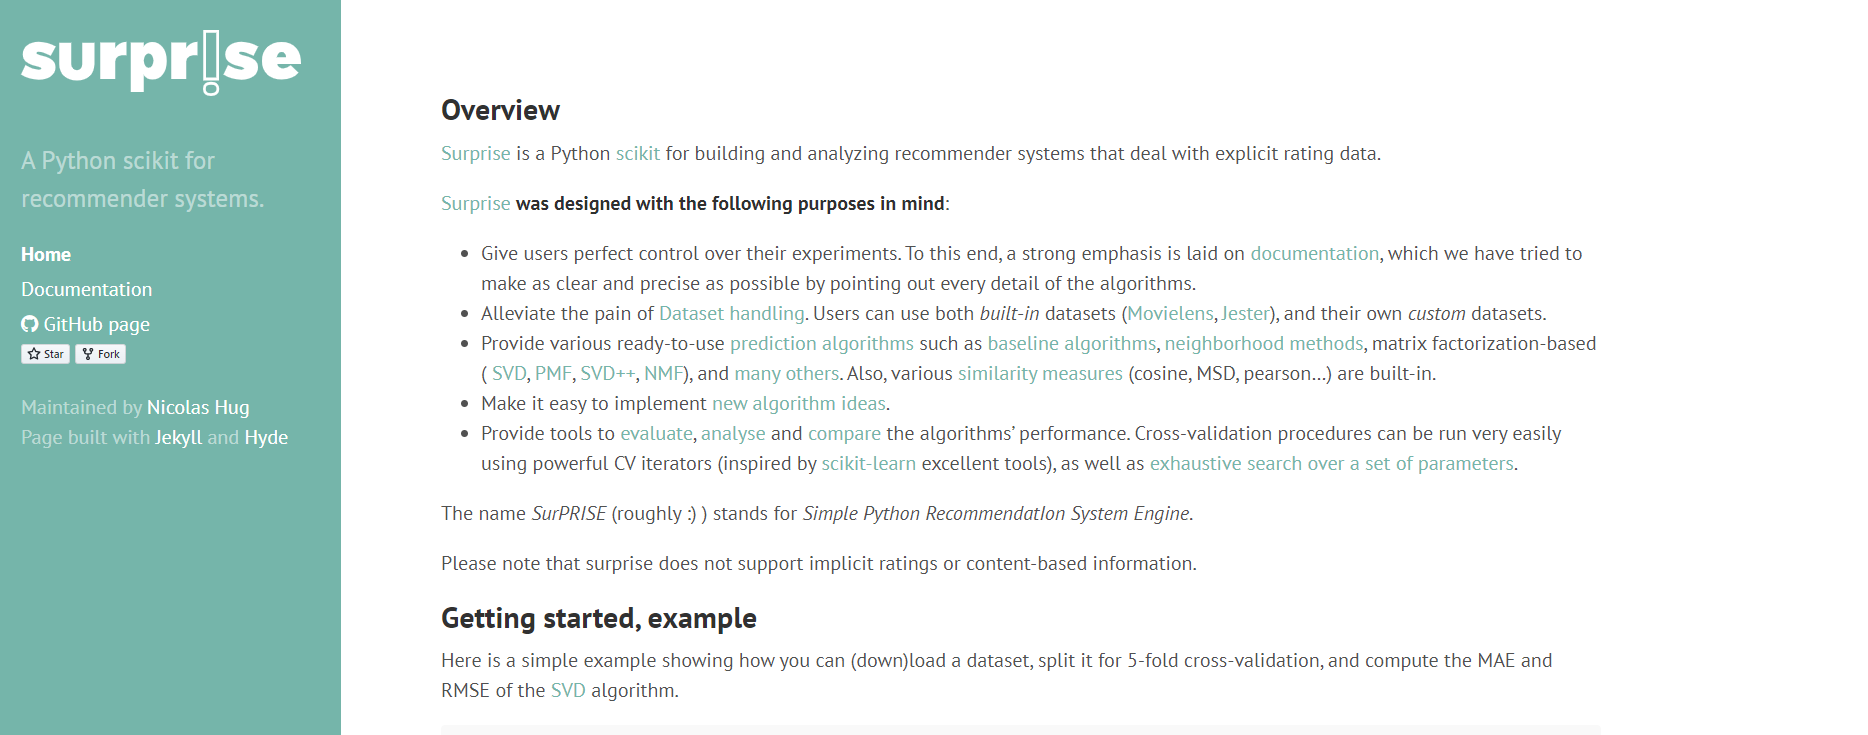

Objectives:
- Give users greater control over their experiments
- Provide various ready-to-use prediction algorithms such as baseline algorithms, neighborhood methods
- Make it easy to implement new algorithm ideas.
- Faciliate evaluation and comparison using cross validation and other tools

#### Inbuilt Libraries

Surprise offers a large number of models. The majority fall into two categories

- KNN: the prediction follows the K Nearest Neighbors algorithm discussed earlier.

- SVD (Singular Value decomposition):  The sparse user-movie ( ratings) matrix "M" is decomposed into a dense matrix by applying matrix factorization techniques. This is very similar to LFM described above. Specifically, M is approximated by USV, where U is "user concept" matrix, S is weights of different concepts and V is a "concept movie" matrix. ‘Concept’ can be intuitively understood by imagining it as a superset of similar movies.  a genre like 'suspense thriller' can be a concept, but the groups may be abstract and multi-dimensional. The dense matrix form USV is directly used for predicting the rating for a (user, movie) pair.

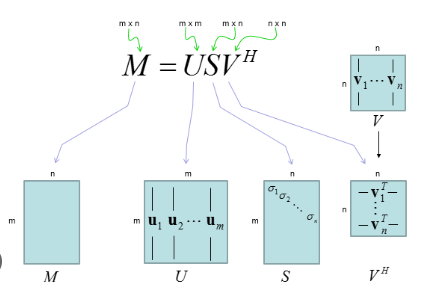

In [50]:

from surprise import Dataset
from surprise.model_selection import cross_validate
from surprise import Reader
from surprise import SVD, SVDpp, SlopeOne, NMF, NormalPredictor
from surprise import KNNBaseline, KNNBasic, KNNWithMeans, KNNWithZScore
from surprise import BaselineOnly, CoClustering


### Loading the data

We’ll be working with data from Book-Crossing, a book ratings dataset. The dataset comprises three tables, we will use two of them: The users table and the book ratings table.

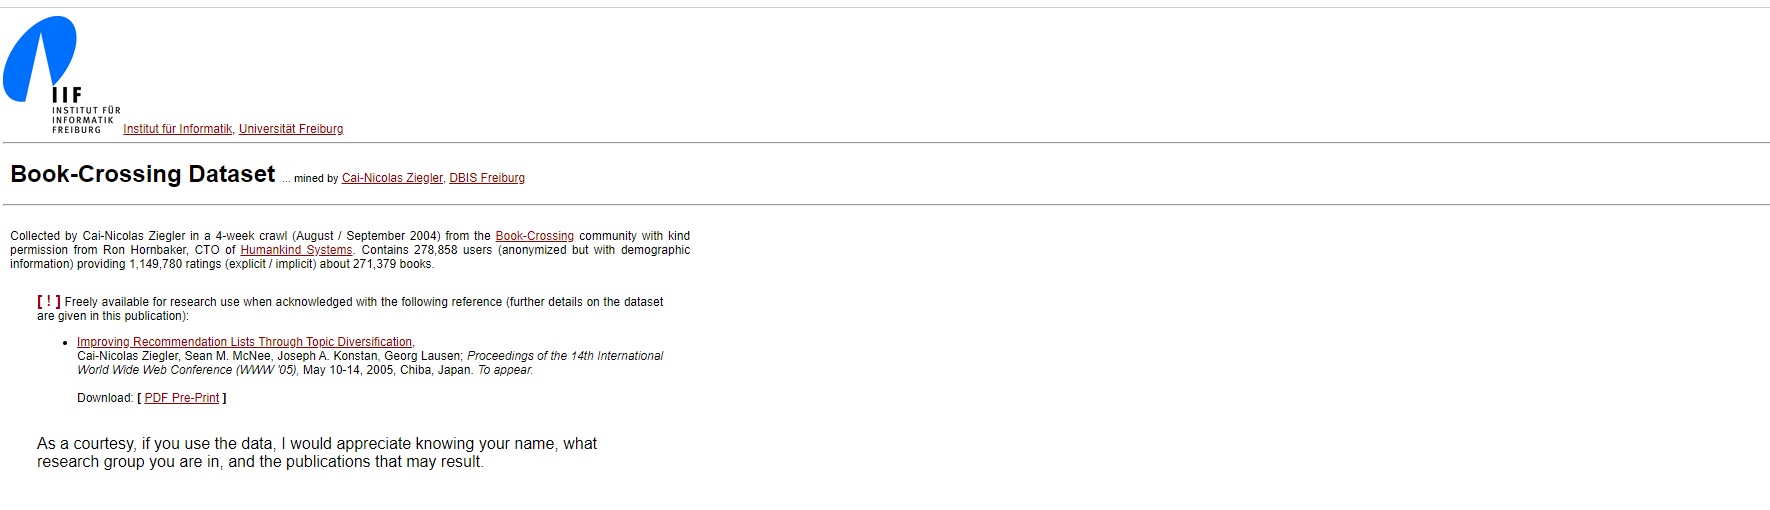

In [51]:
# Download latest version
bookpath = kagglehub.dataset_download("somnambwl/bookcrossing-dataset")

In [ ]:
user = pd.read_csv(bookpath + '/Users.csv', sep=';', on_bad_lines='skip', encoding="latin-1" )
user.columns = ['userID', 'Age']  
user.head(10)

/tmp/ipykernel_40921/436439919.py:1: DtypeWarning:

Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.



,userID,Age
0,1,NaN
1,2,18
2,3,NaN
3,4,17
4,5,NaN
5,6,61
6,7,NaN
7,8,NaN
8,9,NaN
9,10,26


In [53]:
rating = pd.read_csv(bookpath + '/Ratings.csv', sep=';', on_bad_lines='skip', encoding="latin-1")
rating.columns = ['userID', 'ISBN', 'bookRating']
rating.head(5)

,userID,ISBN,bookRating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


Close to 70% of books show a rating of zero. This signifies the user interacted with the book but declined to explicitly rate it. This type of interaction is known as *implict feedback.*  This information could be  valuable.

One of the drawbacks of Surprise is its lack of support for implicit feedback.  For now, we will drop those records. Later, we will see some frameworks which do support implicit framework

<Axes: >

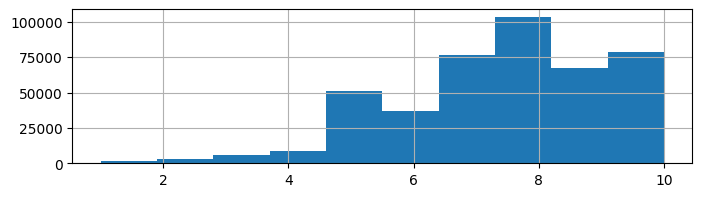

In [54]:
rating = rating[rating.bookRating != 0]  # get rid of 0 ratings
rating.bookRating.hist(figsize=(8,2))

In [55]:
bookdf = pd.merge(user, rating, on='userID', how='inner')
bookdf.drop([ 'Age'], axis=1, inplace=True)
bookdf.head()

,userID,ISBN,bookRating
0,8,0002005018,5
1,8,074322678X,5
2,8,0887841740,5
3,8,1552041778,5
4,8,1567407781,6


### EDA: Ratings Distribution

In [56]:
from plotly.offline import init_notebook_mode, plot, iplot
import plotly.graph_objs as go
init_notebook_mode(connected=True)
data = bookdf['bookRating'].value_counts().sort_index(ascending=False)
trace = go.Bar(x = data.index,
               text = ['{:.1f} %'.format(val) for val in (data.values / bookdf.shape[0] * 100)],
               textposition = 'auto',
               textfont = dict(color = '#000000'),
               y = data.values,
               )
# Create layout
layout = dict(title = 'Distribution Of {} book-ratings'.format(bookdf.shape[0]),              xaxis = dict(title = 'Rating'),              yaxis = dict(title = 'Count'))# Create plotfig = go.Figure(data=[trace], layout=layout)iplot(fig)

In [57]:
# Number of ratings per book
data = bookdf.groupby('ISBN')['bookRating'].count().clip(upper=50)
# Create trace
trace = go.Histogram(x = data.values,
                     name = 'Ratings',
                     xbins = dict(start = 0,
                                  end = 50,
                                  size = 2))
# Create layout
layout = go.Layout(title = 'Distribution Of Number of Ratings Per Book (Clipped at 100)',
                   xaxis = dict(title = 'Number of Ratings Per Book'),
                   yaxis = dict(title = 'Count'),
                   bargap = 0.2)
# Create plot
fig1 = go.Figure(data=[trace], layout=layout)
#iplot(fig1)

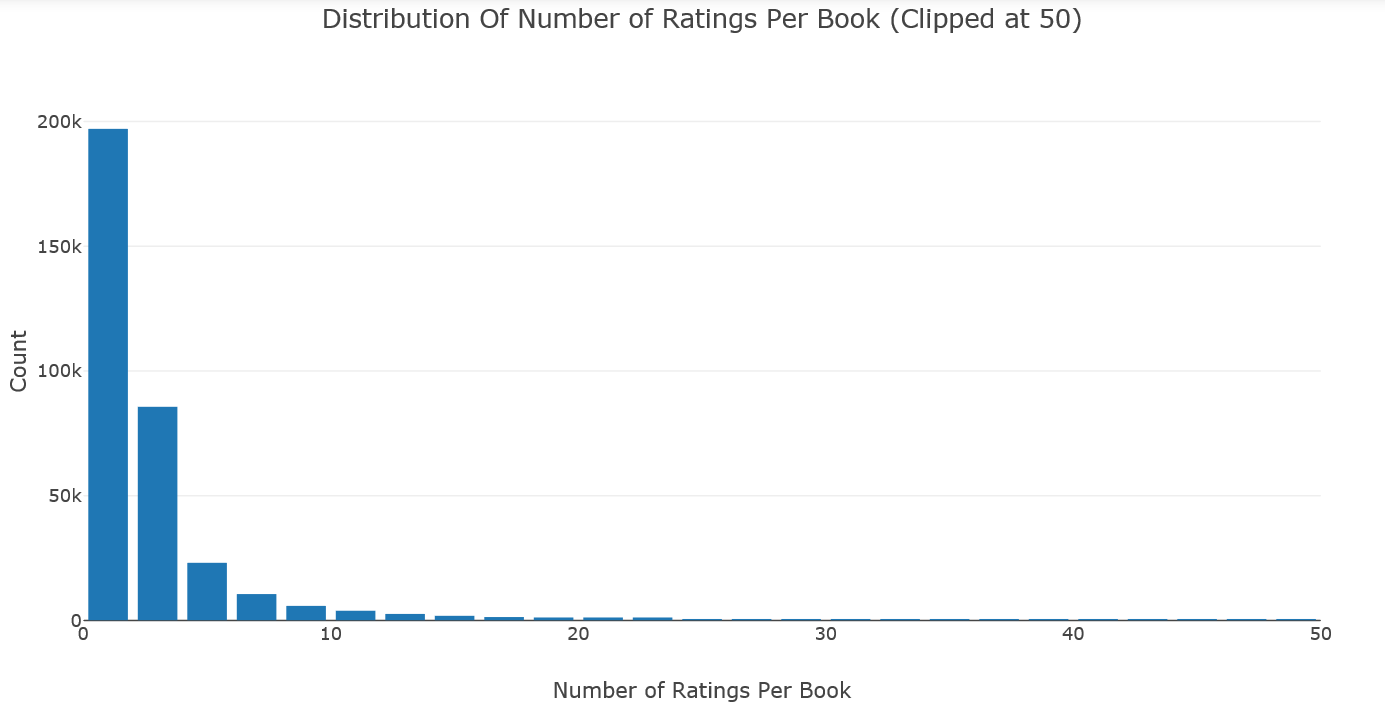

In [58]:
bookdf.groupby('ISBN')['bookRating'].count().reset_index().sort_values('bookRating', ascending=False)[:10]

,ISBN,bookRating
25529,0316666343,663
128253,0971880107,542
43548,0385504209,464
21651,0312195516,359
87484,0679781587,308
5102,0060928336,303
75588,059035342X,295
15491,0142001740,293
57070,0446672211,277
53158,044023722X,267


Most of the books in the data received less than 5 ratings, and very few books have many ratings, although the most rated book has received 663 ratings.

### Ratings Distribution By User

In [59]:
# Number of ratings per user
data = bookdf.groupby('userID')['bookRating'].count().clip(upper=50)
# Create trace
trace = go.Histogram(x = data.values,
                     name = 'Ratings',
                     xbins = dict(start = 0,
                                  end = 50,
                                  size = 2))
# Create layout
layout = go.Layout(title = 'Distribution Of Number of Ratings Per User (Clipped at 50)',
                   xaxis = dict(title = 'Ratings Per User'),
                   yaxis = dict(title = 'Count'),
                   bargap = 0.2)
# Create plot
fig2 = go.Figure(data=[trace], layout=layout)
#iplot(fig2)

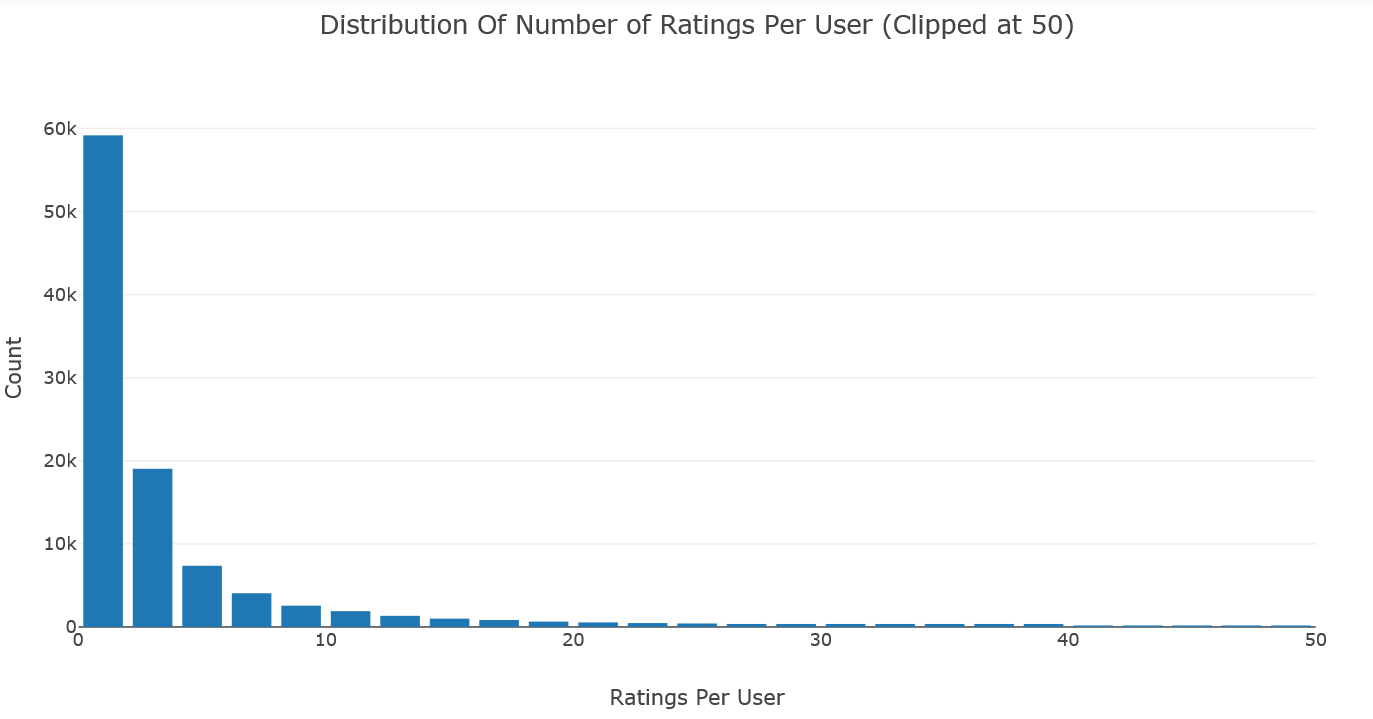

In [60]:
bookdf.groupby('userID')['bookRating'].count().reset_index().sort_values('bookRating', ascending=False)[:10]

,userID,bookRating
3160,11676,8524
27626,98391,5802
43027,153662,1969
52924,189835,1906
6510,23902,1395
21456,76499,1036
47780,171118,1035
65517,235105,1023
4555,16795,968
69413,248718,948


Most of the users in the data gave less than 5 ratings; one prolific user gave 8,524 ratings. 

To reduce the dimensionality of the data set  we will filter out rarely rated books and rarely rating users.    Matrix Factorization techniques consume alot of memory. Without this filtering, Surprise may crash.

In [61]:
min_book_ratings = 10
filter_books = bookdf['ISBN'].value_counts() > min_book_ratings
filter_books = filter_books[filter_books].index.tolist()
min_user_ratings = 10
filter_users = bookdf['userID'].value_counts() > min_user_ratings
filter_users = filter_users[filter_users].index.tolist()
bookdf_new = bookdf[(bookdf['ISBN'].isin(filter_books)) & (bookdf['userID'].isin(filter_users))]
print('The original data frame shape:\t{}'.format(bookdf.shape))
print('The new data frame shape:\t{}'.format(bookdf_new.shape))

The original data frame shape:	(410546, 3)
The new data frame shape:	(76904, 3)


### Using the Surprise framework

To load a data set from the above pandas data frame, we will use the load_from_df() method, we will also need a Reader object, and the rating_scale parameter must be specified. The data frame must have three columns, corresponding to the user ids, the item ids, and the ratings in this order. Each row thus corresponds to a given rating.

In [62]:
reader = Reader(rating_scale=(0, 9))
data = Dataset.load_from_df(bookdf_new[['userID', 'ISBN', 'bookRating']], reader)

### With the Surprise library, we will benchmark the following algorithms:

#### Basic algorithms

1) NormalPredictor. NormalPredictor algorithm predicts a random rating based on the distribution of the training set, which is assumed to be normal. **This basic algorithms frequently fails**

2) BaselineOnly. BaselineOnly algorithm predicts the baseline estimate for given user and item.

#### k-NN algorithms

1) KNNBasic is a basic CF algorithm.

2) KNNWithMeans takes into account the mean ratings of each user.

3) KNNBaseline takes into account a baseline rating.

#### Matrix Factorization-based algorithms

1) SVD algorithm is equivalent to Probabilistic Matrix Factorization

2) The SVDpp algorithm is an extension of SVD that takes into account implicit ratings.

3) NMF is a collaborative filtering algorithm based on Non-negative Matrix Factorization. It is very similar to SVD.

### Other algorithms used by Surprise

SlopeOne https://en.wikipedia.org/wiki/Slope_One#:~:text=Slope%20One%20is%20a%20family,as%20Apache%20Mahout%20and%20Easyrec. is a simple but effective CF algorithm

Coclustering identifies blocs within a matrix. https://cgc-tutorial.readthedocs.io/en/latest/notebooks/coclustering.html 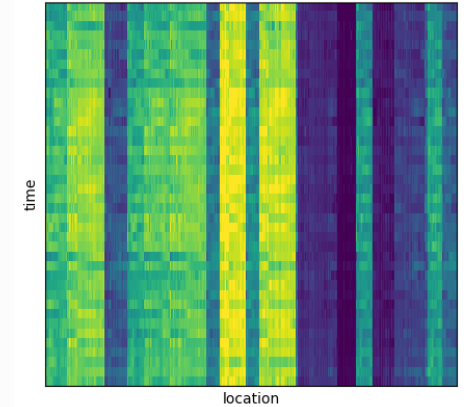


Compare a set of recommendation algorithms using cross-validation with RMSE as the evaluation metric

In [63]:
#allow one minute
benchmark = []
algos = [SVD(), SVDpp(), SlopeOne(), NMF(), NormalPredictor(), KNNBaseline(), KNNBasic(), KNNWithMeans(), KNNWithZScore(), BaselineOnly(), CoClustering()]

for algorithm in algos:
    # Perform cross validation
    results = cross_validate(algorithm, data, measures=['RMSE'], cv=3, verbose=False)
    # Get results & append algorithm name
    tmp = pd.concat([
        pd.DataFrame.from_dict(results).mean(axis=0), 
        pd.Series([str(algorithm).split(' ')[0].split('.')[-1]], index=['Algorithm'])
                     ])
    benchmark.append(tmp)
pd.DataFrame(benchmark).set_index('Algorithm').sort_values('test_rmse') 

Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...


,test_rmse,fit_time,test_time
Algorithm,,,
SVD,1.575350,0.712323,0.139567
SVDpp,1.578031,4.686640,1.332926
BaselineOnly,1.581186,0.153125,0.078170
CoClustering,1.679768,1.467304,0.095329
KNNWithMeans,1.739761,1.405200,0.712180
KNNWithZScore,1.741960,1.476391,0.853258
KNNBaseline,1.742915,1.381906,0.714602
SlopeOne,1.850472,1.574111,0.547170
KNNBasic,1.869831,1.802733,0.647306


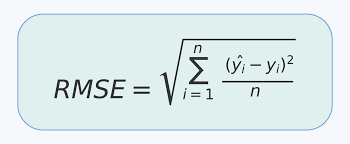


### Training and Prediction

SVD gave us the best rmse. 

Therefore, we will train and predict with SVD and use Alternating Least Squares (ALS).

In [64]:
print('Using SVD with Stochastic Gradient Descent')
algo = SVD( n_epochs=5)
cross_validate(algo, data, measures=['RMSE'], cv=3, verbose=False)

Using SVD with Stochastic Gradient Descent


{'test_rmse': array([1.6279178 , 1.60329832, 1.63597598]),
 'fit_time': (0.17600131034851074, 0.18405771255493164, 0.2124171257019043),
 'test_time': (0.1273801326751709, 0.12008261680603027, 0.17219281196594238)}

We use the train_test_split() to sample a trainset and a testset with given sizes, and use the accuracy metric of rmse. We’ll then use the fit() method which will train the algorithm on the trainset, and the test() method which will return the predictions made from the testset.

In [65]:
from surprise.model_selection import train_test_split
from surprise import accuracy
trainset, testset = train_test_split(data, test_size=0.25, random_state=42)
predictions = algo.fit(trainset).test(testset)
accuracy.rmse(predictions)

RMSE: 1.6152


1.6151657005122584

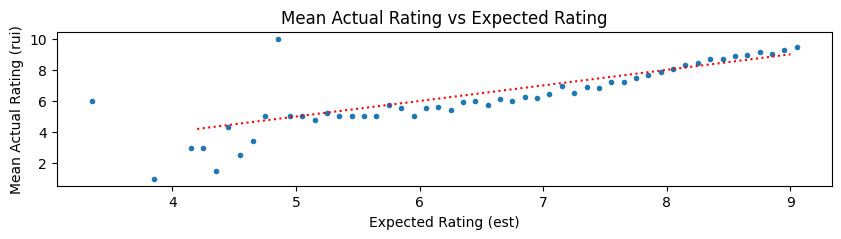

In [67]:
preddf = pd.DataFrame(predictions, columns=['uid', 'iid', 'rui', 'est', 'details'])

preddf['err'] = abs(preddf.est - preddf.rui)
preddf['est2'] = preddf.est.round(1)+.05
mean_actual = preddf.groupby('est2')['rui'].mean()
plt.figure(figsize=(10, 2))
plt.scatter(mean_actual.index, mean_actual.values, marker='.')
#add y=x line red dotted
plt.plot([4.2, 9], [4.2, 9], color='red', linestyle='dotted')
plt.xlabel('Expected Rating (est)')
plt.ylabel('Mean Actual Rating (rui)')
plt.title('Mean Actual Rating vs Expected Rating')
plt.show()

In [ ]:
#Iu and Ui provide additional information
def get_Iu(uid):
    """ return the number of items rated by given user
    args:       uid: the id of the user    
    returns:       the number of items rated by the user    
    """
    try:
        return len(trainset.ur[trainset.to_inner_uid(uid)])
    except ValueError:
        # user was not part of the trainset
        return 0
def get_Ui(iid):
    """ return number of users that have rated given item
    args:      iid: the raw id of the item
    returns:      the number of users that have rated the item.
    """
    try:
        return len(trainset.ir[trainset.to_inner_iid(iid)])
    except ValueError:
        return 0

preddf['Iu'] = preddf.uid.apply(get_Iu)
preddf['Ui'] = preddf.iid.apply(get_Ui)
preddf.head(10)

,uid,iid,rui,est,details,err,est2,Iu,Ui
0,38544,0399147128,8.0,7.896356,{'was_impossible': False},0.103644,7.95,7,8
1,59172,0679731377,5.0,9.000000,{'was_impossible': False},4.000000,9.05,47,8
2,231237,0441001971,9.0,8.759147,{'was_impossible': False},0.240853,8.85,38,16
3,78719,0553262505,6.0,7.795624,{'was_impossible': False},1.795624,7.85,4,19
4,245827,0399141146,10.0,6.957800,{'was_impossible': False},3.042200,7.05,31,17
5,88733,0061000027,9.0,8.276281,{'was_impossible': False},0.723719,8.35,52,9
6,227702,0671776134,8.0,7.742350,{'was_impossible': False},0.257650,7.75,15,14
7,174791,0316103098,5.0,8.069818,{'was_impossible': False},3.069818,8.15,2,9
8,256167,0312976275,8.0,7.921463,{'was_impossible': False},0.078537,7.95,8,48
9,106849,0553582747,10.0,8.898956,{'was_impossible': False},1.101044,8.95,22,32


While the predictions are directionally correct, there is a great deal of individual variation not captured by the model, evidenced by the low R-squared

In [69]:
from sklearn.metrics import r2_score

R_squared = r2_score(preddf.rui, preddf.est)    
print(f'R-squared between predicted and actual ratings: {R_squared:.4f}')

R-squared between predicted and actual ratings: 0.1690


### Let's Now Apply Surprise to the MovieLens Dataset

https://towardsdatascience.com/make-your-own-book-and-movie-recommender-system-using-surprise-42cc1c840a19

We use only a subset of this dataset. 

We upload the ratings to a Surprise Dataset object which contains the following fields in this order:
- userId
- movieId
- The corresponding rating (usually on a scale such as 1–5)

In [70]:
from surprise import Reader
df_ratings = df_ratings.drop(columns="timestamp",errors="ignore")
df_ratings.userId.count()
df_ratings_100k = get_subset(df_ratings, 100000)

# Surprise reader
reader = Reader(rating_scale=(0, 5)) 

# Finally load all ratings
ratings_data = Dataset.load_from_df(df_ratings_100k[['userId', 'movieId', 'rating']], reader)
trainset, testset = train_test_split(ratings_data, test_size=0.25, random_state=42)

In [71]:
## Training and Cross-Validating collaborative filtering models
## Testing different algorithms on MovieLens dataset
## Allow ~4 minutes

algos2 = [SVD(), SVDpp(), BaselineOnly(), CoClustering(), KNNBaseline(), KNNWithZScore()]
benchmark = []

for algo in algos2:

    results = cross_validate(algo, ratings_data, measures=['RMSE'], cv=3, verbose=False)
    tmp = pd.concat([
        pd.DataFrame.from_dict(results).mean(axis=0),
        pd.Series([str(algo).split(' ')[0].split('.')[-1]], index=['Algorithm'])
                   ])
    benchmark.append(tmp)
        
pd.DataFrame(benchmark).set_index('Algorithm').sort_values('test_rmse') 

Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.


,test_rmse,fit_time,test_time
Algorithm,,,
SVDpp,0.869748,57.945411,13.236595
BaselineOnly,0.876718,0.306599,0.094098
SVD,0.881816,0.905456,0.174245
KNNBaseline,0.885250,0.363197,1.760576
KNNWithZScore,0.905900,0.177776,1.757480
CoClustering,0.952592,1.848232,0.331976


SVD++ https://surprise.readthedocs.io/en/stable/matrix_factorization.html  is slow for training and inference time but it slightly outperforms the other methods

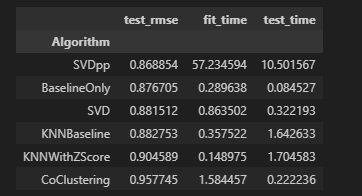

In [72]:
algo = SVDpp( n_epochs=5)
cross_validate(algo, ratings_data, measures=['RMSE'], cv=3, verbose=False)

{'test_rmse': array([0.88550456, 0.89163332, 0.88526076]),
 'fit_time': (14.280402421951294, 15.082779884338379, 14.162301540374756),
 'test_time': (11.147924661636353, 10.729724407196045, 11.38661813735962)}

In [73]:
predictions = algo.fit(trainset).test(testset)
accuracy.rmse(predictions)
preddf = pd.DataFrame(predictions, columns=['uid', 'iid', 'rui', 'est', 'details'])
R_squared = r2_score(preddf.rui, preddf.est)    
print(f'R-squared between predicted and actual ratings: {R_squared:.4f}')

RMSE: 0.8828
R-squared between predicted and actual ratings: 0.2808


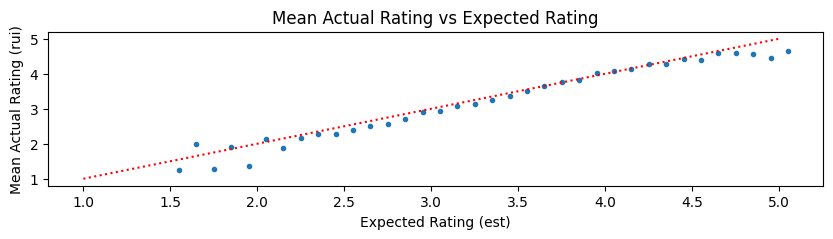

In [74]:
preddf['est2'] = preddf.est.round(1)+.05
mean_actual = preddf.groupby('est2')['rui'].mean()
plt.figure(figsize=(10, 2))
plt.scatter(mean_actual.index, mean_actual.values, marker='.')
plt.plot([1, 5], [1, 5], color='red', linestyle='dotted')
plt.xlabel('Expected Rating (est)')
plt.ylabel('Mean Actual Rating (rui)')
plt.title('Mean Actual Rating vs Expected Rating')
plt.show()

### LightFM

LightFM https://making.lyst.com/lightfm/docs/lightfm.data.html was released in 2015 by Maciej Kula. One of the advantages of this package is support for implicit feedback

In [75]:
# Example: Using LightFM with MovieLens-style data
from lightfm import LightFM
from lightfm.data import Dataset
from scipy import sparse
 
# For implicit feedback, treat ratings > 0 as interactions
df_lightfm = df_ratings.copy()
df_lightfm['interaction'] = (df_lightfm['rating'] > 0).astype(int)
 
# Build LightFM dataset
dataset = Dataset()
dataset.fit(df_lightfm['userId'], df_lightfm['movieId'])
 
# Build interactions matrix
interactions, _ = dataset.build_interactions([(row['userId'], row['movieId']) for idx, row in df_lightfm.iterrows() if row['interaction'] == 1])
 
# Instantiate and train LightFM model
model = LightFM(no_components=30, loss='warp')
model.fit(interactions, epochs=10, num_threads=2)


#### Weighted Approximate-Rank Pairwise loss (WARP)

WARP loss is an improvement over Bayesian Personalized Loss ("BPR") loss.
https://www.sciencedirect.com/science/article/pii/S2666827023000737

This explanation comes from https://ethen8181.github.io/machine-learning/recsys/5_warp.html#:~:text=1p-,Building%20Intuition%20for%20WARP,it%20cannot%20currently%20rank%20correctly.

"For a given user, positive item pair, sample a negative item at random from all the remaining items. Compute predictions for both items; if the negative item's prediction exceeds that of the positive item plus a margin, perform a gradient update so we can rank the positive item higher and the negative item lower. If there is no rank violation, continue sampling negative items until a violation is found"

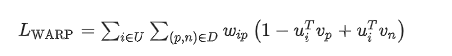

Other references

https://making.lyst.com/lightfm/docs/examples/warp_loss.html

https://medium.com/@gabrieltseng/intro-to-warp-loss-automatic-differentiation-and-pytorch-b6aa5083187a

In [76]:
# Example: Predict for a user and item
for tuple in [(0,5), (1,3), (8,2)]:

    user_id = df_lightfm['userId'].iloc[tuple[0]]
    movie_id = df_lightfm['movieId'].iloc[tuple[1]]
    user_id_map, _, item_id_map, _ = dataset.mapping()
    user_index = user_id_map[user_id]
    item_index = item_id_map[movie_id]
    title = df_movies.query(f'movieId == {movie_id}').title.values[0]
    score = model.predict([user_index], [item_index])
    print(f'Predicted score for user {user_id} and title {title}  : {score}')

Predicted score for user 432 and title Lord of Illusions (1995)  : [-4.931496]
Predicted score for user 288 and title Who Framed Roger Rabbit? (1988)  : [-3.6148233]
Predicted score for user 438 and title Point Break (1991)  : [-5.220233]


## Other Open Source Packages for Recommendation Systems

### TFRS (Tensorflow Recommenders)

TFRS is Tensorflow-based. This is the successor to TensorRec. We ran this code in Google CoLab (see tfrs.ipynb), even there it was a bit finicky. It did the embeddings but the Neighborhood Search did not run cleanly

https://www.tensorflow.org/recommenders/examples/quickstart


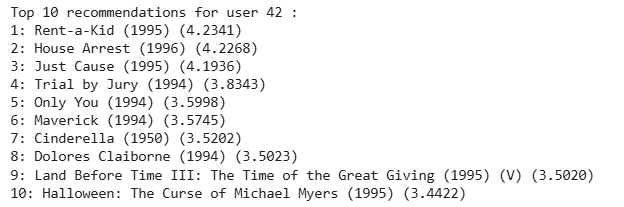

### Spotlight

Spotlight was developed by the author of LightFM. It incorportes deep learning, scales better, and can be customized to support advanced applications. An implementation can be found here 
https://github.com/maciejkula/spotlight

### Implicit

Implicit is another package which supports implict feedback

https://github.com/benfred/implicit/blob/main/examples/lastfm.py


### LensKit for Python ("LKPY")

LensKit is a free, open-source framework for developing, investigating, and learning about recommender systems. It supports developing, running, and assessing recommender algorithms in a flexible manner appropriate for research and education. 

LKPY leverages ecosystems such as scikit-learn and TensorFlow.

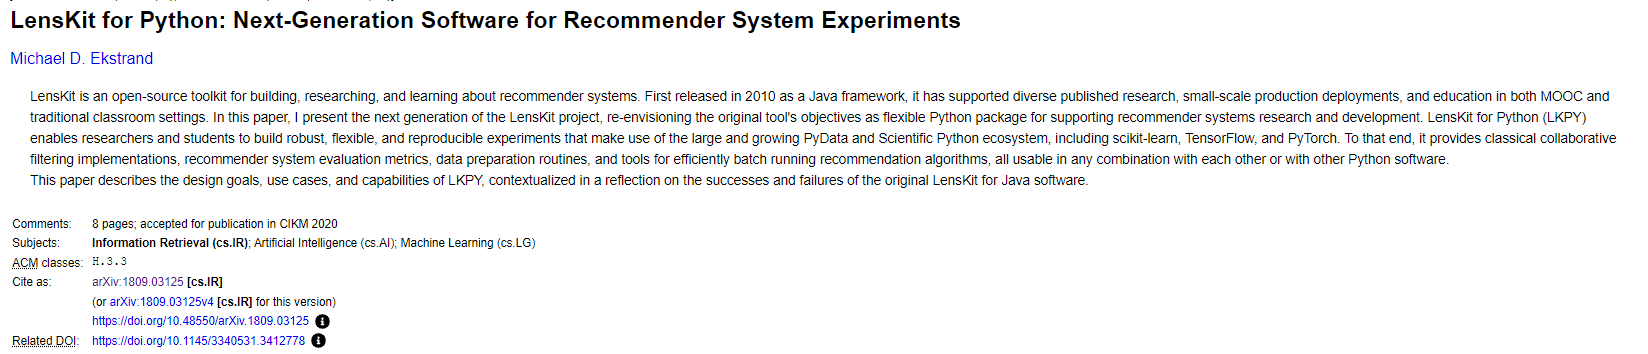

## Specialized Recommenders

#### Sequential Recommender Systems

Sometimes it is useful to predict a user's next decision. Or to consider the user which Harry Potter books the user read before recommending another. Sequential Recommenders may incorporate time series elements such as Recurrent Neural Networks. References: https://milvus.io/ai-quick-reference/what-is-serendipity-in-recommender-systems and https://arxiv.org/pdf/2207.06225


#### Session-Based Recommender System 

These systems focus on user interactions during a particular online session. Youtube and Amazon both utilize session-based recommender systems. When a user’s history (such as previous clicks or transactions) is not available or relevant in the current user session, they are particularly valuable.

References https://milvus.io/ai-quick-reference/what-is-a-sessionbased-recommender-system-and-when-is-it-useful

#### Multi-criteria Recommender Systems

Multi-criteria recommender systems (MCRS) are recommender systems that take into account many factors when making recommendations. Rather than developing recommendation techniques based on a single criterion value, such as user u’s overall preference for an item I, these systems attempt to predict a rating for unexplored items of u by leveraging preference information on multiple criteria that influence this overall preference value. The aggregation function to combine diverse criteria can itself be learned. Several researchers see MCRS as a multi-criteria decision-making (MCDM) problem and construct MCRS systems using MCDM approaches and techniques.

https://pmc.ncbi.nlm.nih.gov/articles/PMC12003883/#:~:text=Multi%2Dcriteria%20recommender%20systems,-MCRSs%20are%20a&text=MCRSs%20can%20make%20more%20personalized,%2Dcriteria%20ratings12%2C28.

### Dating

Dating apps generally rely on CF techniques. There is, however, a well-known algorithm called Gale-Shapley specific to this problem

 (Hinge)https://medium.com/swlh/dating-data-an-overview-of-the-algorithm-afb9f0c08e2c
 
 
This algorithm, utilized by Hinge, pairs people “who are likely to mutually like one another”. It measures this based off your engagement and who engages with you, as well as matches you to people with similar preferences.
 
 The algorithm solves this problem iteratively.  Each subject proposes to its highest ranked partner. the partner responds yes or no — if no, the subject proposes to its next most-preferred partner.. **The matching is considered stable when there is no match that prefer each other over their current partners.**![image-3.png](attachment:image-3.png)

 https://www.scientificamerican.com/article/the-stable-marriage-problem-solution-underpins-dating-apps-and-school/

 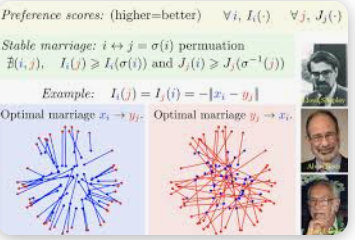

### Peer Grading

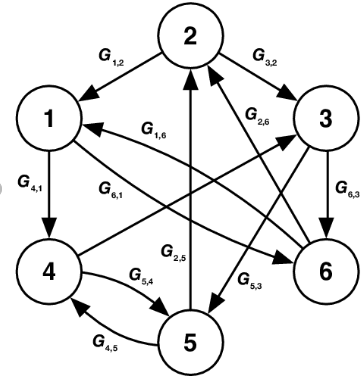

Peer Grading can be viewed as a Collaborative Filtering problem, where a sparse user-user matrix needs to be interpolated. 

How can machine learning be used to improve peer grading?

https://www.researchgate.net/publication/305523260_Improving_Peer_Grading_Reliability_with_Graph_Mining_Techniques

## Integrating Deep Learning and Generative AI with Recommendation Engines

### Ways Deep Learning can be incorporated into a Recommender System ###

- We demonstrated earlier the use of embeddings to represent features in a continuous n-dimensional space.
- We also passed the  user-product matrix through neural layers to learn latent features of users and products.
- The model can be trained using a loss function that minimizes the difference between predicted and actual ratings, such as mean squared error (MSE).
- The output is a set of embeddings for users and products that can be used to predict ratings for user-product pairs not in the original matrix.
- In addition to matrix factorization, the model can use techniques like Collaborative Embedding Distillatuon (CED) to compress the class (model.Model) https://www.mdpi.com/2079-9292/14/8/1538


### Ways GenAI can be incorporated into a Recommender System ###

- The model can incorporate additional features about users (e.g., demographics, preferences) and products (e.g., categories, attributes) to enhance recommendation accuracy.

- The neural network can take in  context : user's recent behavior, proximity to holidays, weather, etc. It could even ask the user what type of product or content (s)he is in the mood for today and reflect that

- Rather than generating a list, an LLM can be prompted to generate a personalized blurb. Images can also be customized


We ran the following code in a **Colab** notebook. With a CPU the script requires approximately 5 minutes, a T4 will be much faster


'May I recommend *The Brothers Karamazov* by Fyodor Dostoevsky? It offers a profound exploration of human emotions, moral dilemmas, and the complexities of life, making it a compelling choice for a deep and thoughtful reading.'

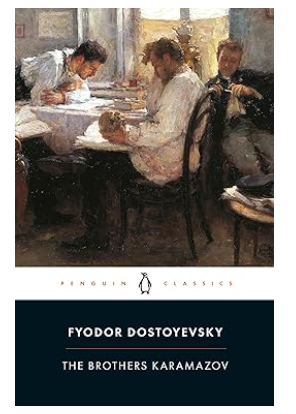

Consider what prompt engineering is required to assure a good recommendation. What risks does a vendor face putting this system into produciton

## Evaluation Methods

How should we evaluate recommender systems? Comparisons are typically made against a baseline. A/B Testing is a common approach.

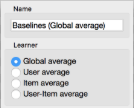

Methods like RecommenderNet try to minimize the global average predictive error.  Some metrics apply refinements for user or product bias 

This paper discusses metrics like Normalized Discounted Cumulative Gain (NDCG) and Serendipity https://www.evidentlyai.com/ranking-metrics/evaluating-recommender-systems


Which metrics are best? It depends Some firms desire very reliable predictions while others seek to promote exploration or maximize clicks



Recommender Systems: A Primer, 2023. Castellsa and Jannach  https://arxiv.org/pdf/2302.02579

This textbook from 2011, updated 2015 https://www.cs.ubbcluj.ro/~gabis/DocDiplome/SistemeDeRecomandare/Recommender_systems_handbook.pdf


